In [1]:
from pathlib import Path
import rasterio
from rasterio.merge import merge
from distmetrics.rio_tools import reproject_arrays_to_target_crs
from dem_stitcher.merge import merge_arrays_with_geometadata
import matplotlib.pyplot as plt
import numpy as np
from rasterio.transform import array_bounds
from tile_mate import get_raster_from_tiles
from rasterio.warp import transform_bounds
from dem_stitcher.rio_tools import reproject_arr_to_match_profile

/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = Path('confirmed_products_melissa/jamiaca_hurrican_melissa/')

In [3]:
status_paths = list(data_dir.rglob('*_20251029T*STATUS.tif'))
metric_paths = list(data_dir.rglob('*_20251029T*METRIC.tif'))
status_acq_paths = list(data_dir.rglob('*_20251029T*STATUS-ACQ.tif'))
status_acq_paths

[PosixPath('confirmed_products_melissa/jamiaca_hurrican_melissa/18QUE/OPERA_L3_DIST-ALERT-S1_T18QUE_20251029T231743Z_20251030T112250Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T18QUE_20251029T231743Z_20251030T112250Z_S1A_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 PosixPath('confirmed_products_melissa/jamiaca_hurrican_melissa/17QRV/OPERA_L3_DIST-ALERT-S1_T17QRV_20251029T231747Z_20251030T112239Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17QRV_20251029T231747Z_20251030T112239Z_S1A_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 PosixPath('confirmed_products_melissa/jamiaca_hurrican_melissa/18QTF/OPERA_L3_DIST-ALERT-S1_T18QTF_20251029T231802Z_20251030T112712Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T18QTF_20251029T231802Z_20251030T112712Z_S1A_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 PosixPath('confirmed_products_melissa/jamiaca_hurrican_melissa/18QUF/OPERA_L3_DIST-ALERT-S1_T18QUF_20251029T231800Z_20251030T111419Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T18QUF_20251029T231800Z_20251030T111419Z_S1A_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 Pos

In [4]:
from rasterio.merge import merge
from distmetrics.rio_tools import reproject_arrays_to_target_crs

In [5]:
def open_one(p: Path):
    with rasterio.open(p) as ds:
        p = ds.profile
        a = ds.read(1)
    return a, p

In [6]:
metrics_l, profs_met_l = zip(*[open_one(p) for p in metric_paths])
statuses_l, profs_stat_l = zip(*[open_one(p) for p in status_paths])
statuses_acq_l, profs_stat_acq_l = zip(*[open_one(p) for p in status_acq_paths])

In [7]:
metrics_crs_l, profs_met_crs_l  = reproject_arrays_to_target_crs(metrics_l, profs_met_l, resampling_method='bilinear')
statuses_crs_l, profs_stat_crs_l  = reproject_arrays_to_target_crs(statuses_l, profs_stat_l, resampling_method='nearest' )
statuses_acq_crs_l, profs_stat_acq_crs_l  = reproject_arrays_to_target_crs(statuses_acq_l, profs_stat_acq_l, resampling_method='nearest' )

In [8]:
X_metric_merged, p_metric_merged = merge_arrays_with_geometadata(metrics_crs_l, profs_met_crs_l)

In [9]:
X_status_merged, p_status_merged = merge_arrays_with_geometadata(statuses_crs_l, profs_stat_crs_l, resampling='nearest')

In [10]:
X_status_acq_merged, p_status_acq_merged = merge_arrays_with_geometadata(statuses_acq_crs_l, profs_stat_acq_crs_l, resampling='nearest')

In [11]:
with rasterio.open(status_paths[0]) as ds:
    cmap = ds.colormap(1)

In [12]:
with rasterio.open('metric_merged_20251029.tif', 'w', **p_metric_merged) as ds:
    ds.write(X_metric_merged)

In [13]:
with rasterio.open('status_merged_20251029.tif', 'w', **p_status_merged) as ds:
    ds.write(X_status_merged)
    ds.write_colormap(1, cmap)

In [14]:
with rasterio.open('status_acq_merged_20251029.tif', 'w', **p_status_acq_merged) as ds:
    ds.write(X_status_acq_merged)
    ds.write_colormap(1, cmap)

In [15]:
X_metric_merged.shape

(1, 7217, 11513)

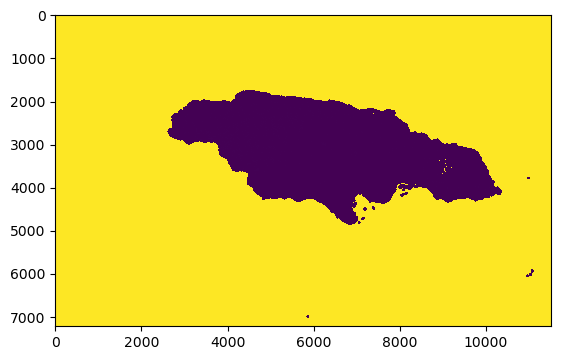

In [17]:
X_m = X_metric_merged[0, ...]
valid_data = ~np.isnan(X_m)
alert_mask = (X_m > 5) & valid_data
X_alert_custom = np.zeros(X_m.shape, dtype='uint8')
X_alert_custom[alert_mask] = 1
X_alert_custom[~valid_data] = 255
plt.imshow(X_alert_custom, interpolation='none')

In [18]:
with rasterio.open('custom_alert.tif', 'w', **p_status_acq_merged) as ds:
    ds.write(X_alert_custom, 1)
    #ds.write_colormap(1, cmap)

In [19]:
def get_bounds_from_profile(profile):
    height, width = profile["height"], profile["width"]
    transform = profile["transform"]
    return array_bounds(height, width, transform)

In [20]:
b = get_bounds_from_profile(p_status_acq_merged)
b

(64417.70371326181, 1887445.3616103977, 409807.7037132618, 2103955.3616103977)

In [21]:

b_4326 = transform_bounds(p_status_acq_merged['crs'], 'epsg:4326', *b)

In [22]:
X_esa_wc, p_esa_wc = get_raster_from_tiles(b_4326, tile_shortname='esa_world_cover_2021')

Reading tile imagery: 100%|█████| 4/4 [00:02<00:00,  1.69it/s]


In [23]:
X_esa_wc_r, p_esa_wc_r = reproject_arr_to_match_profile(X_esa_wc, p_esa_wc, p_status_acq_merged, resampling='nearest')

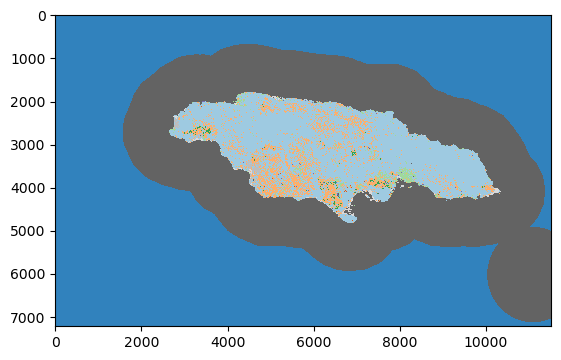

In [24]:
plt.imshow(X_esa_wc_r[0, ...], cmap='tab20c', interpolation='none')

In [26]:
with rasterio.open('landcover_esa.tif', 'w', **p_status_acq_merged) as ds:
    ds.write(X_esa_wc)
    #ds.write_colormap(1, cmap)

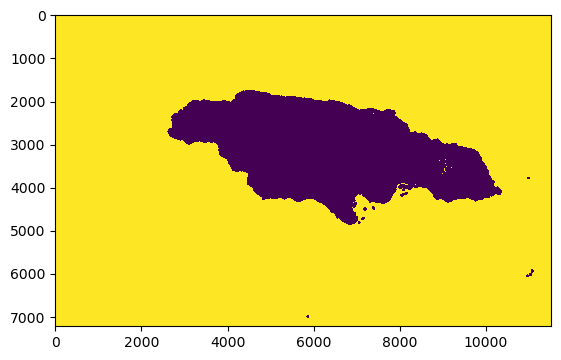

In [37]:
X_m = X_metric_merged[0, ...]
valid_data = ~np.isnan(X_m)
low_alert_mask = (X_m > 5) & valid_data & (X_esa_wc_r[0, ...] !=10)
high_alert_mask = (X_m > 7.5) & valid_data & (X_esa_wc_r[0, ...] !=10)

X_alert_custom = np.zeros(X_m.shape, dtype='uint8')
X_alert_custom[low_alert_mask] = 1
X_alert_custom[high_alert_mask] = 2
X_alert_custom[~valid_data] = 255
plt.imshow(X_alert_custom, interpolation='none')

In [38]:
custom_colormap = {
    0: (255, 255, 255, 255),  # white, fully opaque
    1: (255, 204, 204, 255),  # light red, fully opaque
    2: (255, 0, 0, 255),      # red, fully opaque
    255: (0, 0, 0, 0)         # transparent for nodata
}

In [39]:
with rasterio.open('custom_alert_trees_masked.tif', 'w', **p_status_acq_merged) as ds:
    ds.write(X_alert_custom, 1)
    ds.write_colormap(1, custom_colormap)

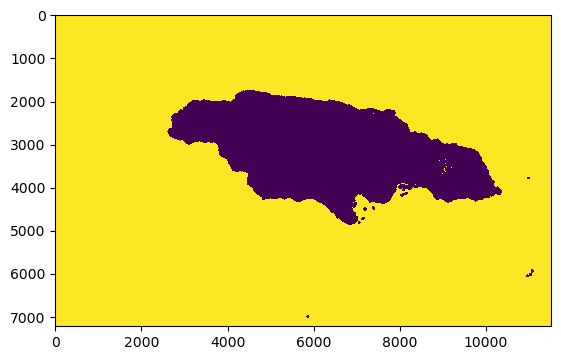

In [43]:
X_m = X_metric_merged[0, ...]
valid_data = ~np.isnan(X_m)
low_alert_mask = (X_m > 5) & valid_data & (X_esa_wc_r[0, ...] !=10)
high_alert_mask = (X_m > 7.5) & valid_data #& (X_esa_wc_r[0, ...] !=10)

X_alert_custom_without_mask = np.zeros(X_m.shape, dtype='uint8')
X_alert_custom_without_mask[low_alert_mask] = 1
X_alert_custom_without_mask[high_alert_mask] = 2
X_alert_custom_without_mask[~valid_data] = 255
plt.imshow(X_alert_custom_without_mask, interpolation='none')

In [44]:
with rasterio.open('custom_alert.tif', 'w', **p_status_acq_merged) as ds:
    ds.write(X_alert_custom_without_mask, 1)
    ds.write_colormap(1, custom_colormap)